In [1]:
# ============================================================
# PINN para lahar por etapas (z_b fijo, sin Exner)
# Aprende: h, u, v, C, p
# ============================================================
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, optimizers
import matplotlib.pyplot as plt
tf.random.set_seed(7)
np.random.seed(7)

2026-03-25 23:54:39.986561: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-25 23:54:40.031954: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/djara/miniconda3/envs/tf216/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
# ============================================================
# SELECCIÓN DE TOPOGRAFÍA
# ============================================================
TOPO_SCENARIO = 1 # 1: plano inclinado, 2: valle gaussiano, 3: canal sinuoso
# ============================================================
# 1) PARÁMETROS FÍSICOS
# ============================================================
g = 9.81
rho_m = 1800.0
mu0 = 0.20
alpha_C = 1.2
alpha_p = 4.0
C0 = 0.45
p_ref = 1e4
kappa_C = 5.0
tau_C = 1e9 # relajación casi nula para C
tau_p = 120.0
chi_p = 0.35
u_star = 1.0
C_star = 0.05
eps_u = 1e-3
eps_h = 1e-6
# ============================================================
# 2) DOMINIO
# ============================================================
Lx = 10_000.0
Ly = 2_000.0
Tmax = 1_200.0
x_min, x_max = 0.0, Lx
y_min, y_max = -Ly/2, Ly/2
t_min, t_max = 0.0, Tmax
# Normalización
x_scale = Lx
y_scale = Ly/2
t_scale = Tmax
h_scale = 10.0
u_scale = 10.0
p_scale = rho_m * g * h_scale

In [3]:
# ============================================================
# 3) TOPOGRAFÍA FIJA z_b(x,y)
# ============================================================
def zb0_physical(x, y):
    if TOPO_SCENARIO == 1:
        Sx = 0.10
        z0 = 3000.0
        return z0 - Sx * x

    elif TOPO_SCENARIO == 2:
        Sx = 0.06
        z0 = 2900.0
        valley_depth = 120.0
        sigma_y = 350.0
        return (z0 - Sx * x) - valley_depth * tf.exp(-(y**2)/(2 * sigma_y**2))

    else:
        Sx = 0.07
        z0 = 2950.0
        A1 = 25.0
        A2 = 15.0
        kx = 2 * np.pi / 2500.0
        ky = 2 * np.pi / 800.0
        return (z0 - Sx * x) + A1 * tf.sin(kx * x) - A2 * tf.cos(ky * y)

def grad_zb_fixed(x, y):
    """
    Gradiente de la topografía fija.
    Se calcula aparte para evitar NoneType en Graph mode.
    """
    with tf.GradientTape(persistent=True) as tape:
        tape.watch([x, y])
        zb = zb0_physical(x, y)
    zb_x = tape.gradient(zb, x)
    zb_y = tape.gradient(zb, y)
    del tape
    return zb_x, zb_y

# ============================================================
# 4) CONDICIONES INICIALES
# ============================================================
def ic_h_physical(x, y):
    x0, y0 = 1200.0, 0.0
    sigx, sigy = 900.0, 450.0
    h0 = 8.0
    return h0 * tf.exp(-((x - x0)**2 / (2 * sigx**2) + (y - y0)**2 / (2 * sigy**2)))

def ic_u_physical(x, y):
    return tf.zeros_like(x)

def ic_v_physical(x, y):
    return tf.zeros_like(y)

def ic_C_physical(x, y):
    C_bg = 0.35
    C_peak = 0.25
    x0, y0 = 1200.0, 0.0
    sigx, sigy = 1000.0, 550.0
    C = C_bg + C_peak * tf.exp(-((x - x0)**2 / (2 * sigx**2) + (y - y0)**2 / (2 * sigy**2)))
    return tf.clip_by_value(C, 0.2, 0.75)

def ic_p_physical(x, y):
    return 0.2 * rho_m * g * ic_h_physical(x, y)

# ============================================================
# 5) MUESTREO DE PUNTOS
# ============================================================
N_ic = 4000
N_pde = 30000
N_bc = 4000

# IC (t=0)
x_ic = tf.random.uniform((N_ic, 1), x_min, x_max, dtype=tf.float32)
y_ic = tf.random.uniform((N_ic, 1), y_min, y_max, dtype=tf.float32)
t_ic = tf.zeros_like(x_ic)

h_ic = ic_h_physical(x_ic, y_ic)
u_ic = ic_u_physical(x_ic, y_ic)
v_ic = ic_v_physical(x_ic, y_ic)
C_ic = ic_C_physical(x_ic, y_ic)
p_ic = ic_p_physical(x_ic, y_ic)

# PDE collocation
x_pde = tf.random.uniform((N_pde, 1), x_min, x_max, dtype=tf.float32)
y_pde = tf.random.uniform((N_pde, 1), y_min, y_max, dtype=tf.float32)
t_pde = tf.random.uniform((N_pde, 1), t_min, t_max, dtype=tf.float32)

# BC laterales
x_bc = tf.random.uniform((N_bc, 1), x_min, x_max, dtype=tf.float32)
t_bc = tf.random.uniform((N_bc, 1), t_min, t_max, dtype=tf.float32)
y_bc_top = tf.ones_like(x_bc) * y_max
y_bc_bot = tf.ones_like(x_bc) * y_min

2026-03-25 23:54:41.942896: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-25 23:54:41.950541: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-25 23:54:41.950579: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-25 23:54:41.951939: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-25 23:54:41.951993: I external/local_xla/xla/stream_executor

In [4]:
# ============================================================
# 6) RED NEURONAL: (x,y,t) -> (h,u,v,C,p)
# ============================================================
Cmax = 0.85

inputs = tf.keras.Input(shape=(3,))
x = layers.Dense(96, activation='tanh')(inputs)
x = layers.Dense(96, activation='tanh')(x)
x = layers.Dense(96, activation='tanh')(x)
x = layers.Dense(96, activation='tanh')(x)
out_raw = layers.Dense(5, activation='linear')(x)

model = tf.keras.Model(inputs=inputs, outputs=out_raw)
opt = optimizers.Adam(learning_rate=1e-3)
mse = tf.keras.losses.MeanSquaredError()

@tf.function
def predict_fields(xm, ym, tm):
    xn = xm / x_scale
    yn = ym / y_scale
    tn = tm / t_scale
    inp = tf.concat([xn, yn, tn], axis=1)
    raw = model(inp)

    h_raw = raw[:, 0:1]
    u_raw = raw[:, 1:2]
    v_raw = raw[:, 2:3]
    C_raw = raw[:, 3:4]
    p_raw = raw[:, 4:5]

    h = tf.nn.softplus(h_raw) * h_scale
    u = u_raw * u_scale
    v = v_raw * u_scale
    C = tf.sigmoid(C_raw) * Cmax
    p = tf.nn.softplus(p_raw) * p_scale

    return h, u, v, C, p


In [5]:
# ============================================================
# 7) CIERRES FÍSICOS
# ============================================================
@tf.function
def mu_eff(C, p, h):
    denom = rho_m * g * h + p_ref
    return mu0 * (1.0 + alpha_C * (C - C0)) * tf.exp(-alpha_p * (p / denom))

@tf.function
def cos_theta(zb_x, zb_y):
    return 1.0 / tf.sqrt(1.0 + zb_x**2 + zb_y**2)

@tf.function
def p_eq(h, C, u, v):
    speed = tf.sqrt(u**2 + v**2 + eps_u)
    phiC = C / (C + C_star)
    return chi_p * rho_m * g * h * phiC * (speed / (speed + u_star))

# ============================================================
# 8) RESIDUOS PDE (SIN Exner, z_b FIJO)
# ============================================================
@tf.function
def pde_residuals(xm, ym, tm):
    # Primer y segundo orden para h,u,v,C,p
    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch([xm, ym, tm])
        with tf.GradientTape(persistent=True) as tape1:
            tape1.watch([xm, ym, tm])

            h, u, v, C, p = predict_fields(xm, ym, tm)
            zb = zb0_physical(xm, ym)
            H = h + zb
            hu = h * u
            hv = h * v

        # 1er orden
        h_t = tape1.gradient(h, tm)
        hu_x = tape1.gradient(hu, xm)
        hv_y = tape1.gradient(hv, ym)

        u_t = tape1.gradient(u, tm)
        u_x = tape1.gradient(u, xm)
        u_y = tape1.gradient(u, ym)

        v_t = tape1.gradient(v, tm)
        v_x = tape1.gradient(v, xm)
        v_y = tape1.gradient(v, ym)

        H_x = tape1.gradient(H, xm)
        H_y = tape1.gradient(H, ym)

        C_t = tape1.gradient(C, tm)
        C_x = tape1.gradient(C, xm)
        C_y = tape1.gradient(C, ym)

        p_t = tape1.gradient(p, tm)
        p_x = tape1.gradient(p, xm)
        p_y = tape1.gradient(p, ym)

    # 2do orden
    C_xx = tape2.gradient(C_x, xm)
    C_yy = tape2.gradient(C_y, ym)

    del tape1
    del tape2

    # Gradiente topografía fija (separado)
    zb_x, zb_y = grad_zb_fixed(xm, ym)

    # Seguridad extra por si alguna derivada sale None
    if C_xx is None:
        C_xx = tf.zeros_like(xm)
    if C_yy is None:
        C_yy = tf.zeros_like(ym)
    if zb_x is None:
        zb_x = tf.zeros_like(xm)
    if zb_y is None:
        zb_y = tf.zeros_like(ym)

    # (1) Masa
    S_h = 0.0
    f_mass = h_t + hu_x + hv_y - S_h

    # Fricción basal
    speed = tf.sqrt(u**2 + v**2 + eps_u)
    mu = mu_eff(C, p, h)
    cth = cos_theta(zb_x, zb_y)

    tau_b = mu * rho_m * g * h * cth
    tau_bx = tau_b * (u / (speed + eps_u))
    tau_by = tau_b * (v / (speed + eps_u))

    # (2) Momento x
    f_momx = u_t + u * u_x + v * u_y + g * H_x + tau_bx / (rho_m * (h + eps_h))

    # (3) Momento y
    f_momy = v_t + u * v_x + v * v_y + g * H_y + tau_by / (rho_m * (h + eps_h))

    # (4) Concentración
    C_eq_val = 0.45
    f_C = C_t + u * C_x + v * C_y - (kappa_C * (C_xx + C_yy) + (C_eq_val - C) / tau_C)

    # (5) Presión de poros
    peq = p_eq(h, C, u, v)
    f_p = p_t + u * p_x + v * p_y - (peq - p) / tau_p

    return f_mass, f_momx, f_momy, f_C, f_p


In [6]:
# ============================================================
# 9) PÉRDIDAS
# ============================================================
@tf.function
def loss_ic():
    h_pred, u_pred, v_pred, C_pred, p_pred = predict_fields(x_ic, y_ic, t_ic)
    L = (
        mse(h_ic, h_pred) +
        mse(u_ic, u_pred) +
        mse(v_ic, v_pred) +
        mse(C_ic, C_pred) +
        mse(p_ic, p_pred)
    )
    return L

@tf.function
def loss_bc():
    h_top, _, _, _, _ = predict_fields(x_bc, y_bc_top, t_bc)
    h_bot, _, _, _, _ = predict_fields(x_bc, y_bc_bot, t_bc)
    return mse(tf.zeros_like(h_top), h_top) + mse(tf.zeros_like(h_bot), h_bot)

@tf.function
def loss_pde_stage2(xb, yb, tb):
    f_mass, f_momx, f_momy, _, _ = pde_residuals(xb, yb, tb)
    return (
        tf.reduce_mean(tf.square(f_mass)) +
        tf.reduce_mean(tf.square(f_momx)) +
        tf.reduce_mean(tf.square(f_momy))
    )

@tf.function
def loss_pde_stage3(xb, yb, tb):
    f_mass, f_momx, f_momy, f_C, f_p = pde_residuals(xb, yb, tb)
    return (
        tf.reduce_mean(tf.square(f_mass)) +
        tf.reduce_mean(tf.square(f_momx)) +
        tf.reduce_mean(tf.square(f_momy)) +
        tf.reduce_mean(tf.square(f_C)) +
        tf.reduce_mean(tf.square(f_p))
    )


In [7]:
# ============================================================
# 10) ENTRENAMIENTO POR ETAPAS
# ============================================================
pde_batch = 4096

# -------- ETAPA 1 --------
epochs_stage1 = 2000
lambda_ic_1 = 5.0
lambda_bc_1 = 2.0

@tf.function
def train_step_stage1():
    with tf.GradientTape() as tape:
        Lic = loss_ic()
        Lbc = loss_bc()
        L = lambda_ic_1 * Lic + lambda_bc_1 * Lbc
    grads = tape.gradient(L, model.trainable_variables)
    opt.apply_gradients(zip(grads, model.trainable_variables))
    return L, Lic, Lbc

print("\n==============================")
print("ETAPA 1: Ajuste de IC + BC")
print("==============================")
for ep in range(epochs_stage1):
    L, Lic, Lbc = train_step_stage1()
    if (ep + 1) % 100 == 0:
        print(f"[Stage 1] Epoch {ep+1}/{epochs_stage1} | Total {L.numpy():.3e} | IC {Lic.numpy():.3e} | BC {Lbc.numpy():.3e}")

# -------- ETAPA 2 --------
epochs_stage2 = 1500
lambda_ic_2 = 5.0
lambda_bc_2 = 2.0
lambda_pde_2 = 5.0

@tf.function
def train_step_stage2():
    idx = tf.random.uniform((pde_batch,), 0, N_pde, dtype=tf.int32)
    xb = tf.gather(x_pde, idx)
    yb = tf.gather(y_pde, idx)
    tb = tf.gather(t_pde, idx)

    with tf.GradientTape() as tape:
        Lic = loss_ic()
        Lbc = loss_bc()
        Lpde = loss_pde_stage2(xb, yb, tb)
        L = lambda_ic_2 * Lic + lambda_bc_2 * Lbc + lambda_pde_2 * Lpde
    grads = tape.gradient(L, model.trainable_variables)
    opt.apply_gradients(zip(grads, model.trainable_variables))
    return L, Lic, Lbc, Lpde

print("\n==============================")
print("ETAPA 2: IC + BC + masa/momento")
print("==============================")
for ep in range(epochs_stage2):
    L, Lic, Lbc, Lpde = train_step_stage2()
    if (ep + 1) % 100 == 0:
        print(f"[Stage 2] Epoch {ep+1}/{epochs_stage2} | Total {L.numpy():.3e} | IC {Lic.numpy():.3e} | BC {Lbc.numpy():.3e} | PDE {Lpde.numpy():.3e}")

# -------- ETAPA 3 --------
epochs_stage3 = 3000
lambda_ic_3 = 1.0
lambda_bc_3 = 1.0
lambda_pde_3 = 20.0

@tf.function
def train_step_stage3():
    idx = tf.random.uniform((pde_batch,), 0, N_pde, dtype=tf.int32)
    xb = tf.gather(x_pde, idx)
    yb = tf.gather(y_pde, idx)
    tb = tf.gather(t_pde, idx)

    with tf.GradientTape() as tape:
        Lic = loss_ic()
        Lbc = loss_bc()
        Lpde = loss_pde_stage3(xb, yb, tb)
        L = lambda_ic_3 * Lic + lambda_bc_3 * Lbc + lambda_pde_3 * Lpde
    grads = tape.gradient(L, model.trainable_variables)
    opt.apply_gradients(zip(grads, model.trainable_variables))
    return L, Lic, Lbc, Lpde

print("\n==============================")
print("ETAPA 3: IC + BC + PDE completas")
print("==============================")
for ep in range(epochs_stage3):
    L, Lic, Lbc, Lpde = train_step_stage3()
    if (ep + 1) % 100 == 0:
        print(f"[Stage 3] Epoch {ep+1}/{epochs_stage3} | Total {L.numpy():.3e} | IC {Lic.numpy():.3e} | BC {Lbc.numpy():.3e} | PDE {Lpde.numpy():.3e}")

print("\nEntrenamiento por etapas completado correctamente.")



ETAPA 1: Ajuste de IC + BC
[Stage 1] Epoch 100/2000 | Total 1.432e+08 | IC 2.863e+07 | BC 1.501e+00
[Stage 1] Epoch 200/2000 | Total 1.211e+08 | IC 2.422e+07 | BC 1.089e+00
[Stage 1] Epoch 300/2000 | Total 1.142e+08 | IC 2.284e+07 | BC 7.751e-01
[Stage 1] Epoch 400/2000 | Total 1.085e+08 | IC 2.170e+07 | BC 6.515e-01
[Stage 1] Epoch 500/2000 | Total 1.043e+08 | IC 2.086e+07 | BC 5.813e-01
[Stage 1] Epoch 600/2000 | Total 1.015e+08 | IC 2.031e+07 | BC 5.318e-01
[Stage 1] Epoch 700/2000 | Total 9.981e+07 | IC 1.996e+07 | BC 4.930e-01
[Stage 1] Epoch 800/2000 | Total 9.876e+07 | IC 1.975e+07 | BC 4.614e-01
[Stage 1] Epoch 900/2000 | Total 9.811e+07 | IC 1.962e+07 | BC 4.346e-01
[Stage 1] Epoch 1000/2000 | Total 9.764e+07 | IC 1.953e+07 | BC 4.117e-01
[Stage 1] Epoch 1100/2000 | Total 9.727e+07 | IC 1.945e+07 | BC 3.916e-01
[Stage 1] Epoch 1200/2000 | Total 9.695e+07 | IC 1.939e+07 | BC 3.740e-01
[Stage 1] Epoch 1300/2000 | Total 9.666e+07 | IC 1.933e+07 | BC 3.580e-01
[Stage 1] Epoch 140

==============================
ETAPA 1: Ajuste de IC + BC
==============================
[Stage 1] Epoch 100/800 | Total 2.830e+07 | IC 2.830e+07 | BC 1.765e+00
[Stage 1] Epoch 200/800 | Total 2.384e+07 | IC 2.384e+07 | BC 1.075e+00
[Stage 1] Epoch 300/800 | Total 2.241e+07 | IC 2.241e+07 | BC 6.974e-01
[Stage 1] Epoch 400/800 | Total 2.123e+07 | IC 2.123e+07 | BC 5.377e-01
[Stage 1] Epoch 500/800 | Total 2.037e+07 | IC 2.037e+07 | BC 4.476e-01
[Stage 1] Epoch 600/800 | Total 1.983e+07 | IC 1.983e+07 | BC 3.882e-01
[Stage 1] Epoch 700/800 | Total 1.952e+07 | IC 1.952e+07 | BC 3.460e-01
[Stage 1] Epoch 800/800 | Total 1.936e+07 | IC 1.936e+07 | BC 3.149e-01

==============================
ETAPA 2: IC + BC + masa/momento
==============================
[Stage 2] Epoch 100/1200 | Total 1.900e+08 | IC 1.900e+07 | BC 5.286e-01 | PDE 8.202e-02
[Stage 2] Epoch 200/1200 | Total 1.882e+08 | IC 1.882e+07 | BC 4.830e-01 | PDE 6.524e-02
[Stage 2] Epoch 300/1200 | Total 1.203e+08 | IC 1.203e+07 | BC 2.796e-01 | PDE 1.113e-01
[Stage 2] Epoch 400/1200 | Total 9.623e+07 | IC 9.623e+06 | BC 1.358e-01 | PDE 5.100e-02
[Stage 2] Epoch 500/1200 | Total 9.512e+07 | IC 9.512e+06 | BC 9.174e-02 | PDE 4.135e-02
[Stage 2] Epoch 600/1200 | Total 9.416e+07 | IC 9.416e+06 | BC 6.417e-02 | PDE 3.690e-02
[Stage 2] Epoch 700/1200 | Total 9.165e+07 | IC 9.165e+06 | BC 4.915e-02 | PDE 5.742e-02
[Stage 2] Epoch 800/1200 | Total 1.021e+07 | IC 1.021e+06 | BC 2.926e-02 | PDE 1.245e-01
[Stage 2] Epoch 900/1200 | Total 2.595e+06 | IC 2.595e+05 | BC 3.498e-02 | PDE 8.728e-02
...
[Stage 3] Epoch 1400/1500 | Total 2.235e+05 | IC 4.471e+04 | BC 1.124e-02 | PDE 1.303e-01
[Stage 3] Epoch 1500/1500 | Total 1.768e+05 | IC 3.536e+04 | BC 1.044e-02 | PDE 8.959e-02

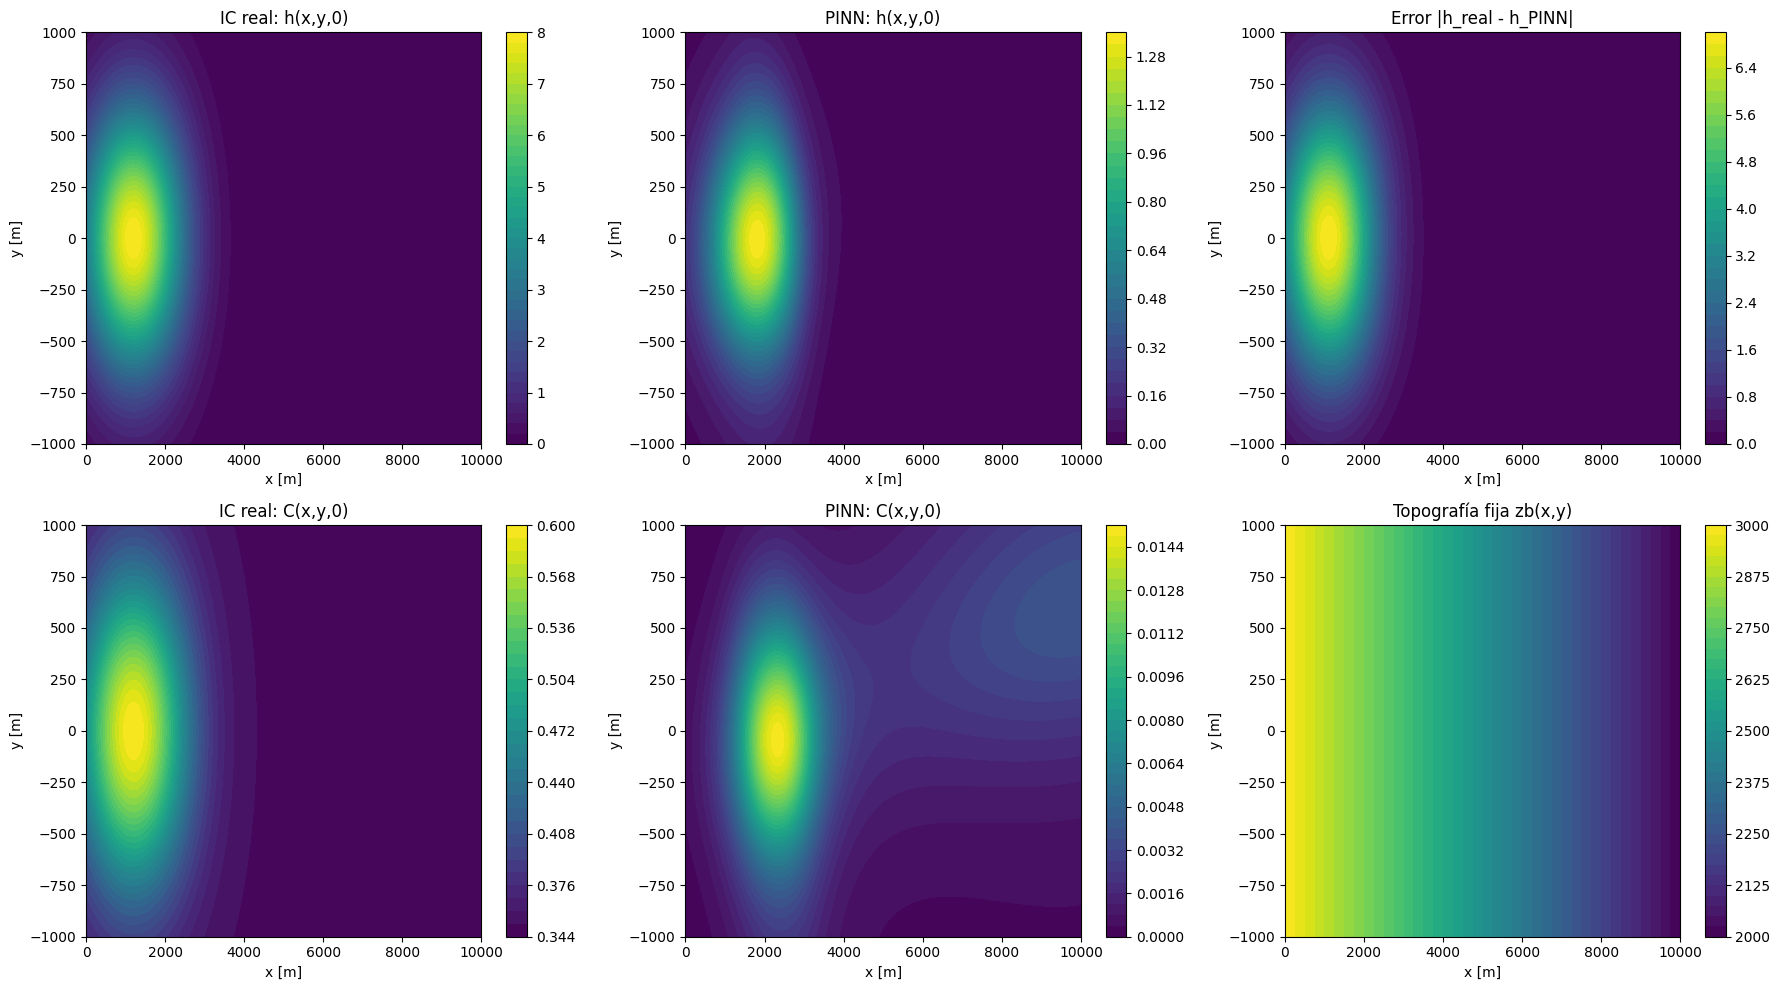

In [8]:
# ============================================================
# 11) VERIFICACIÓN DE CONDICIÓN INICIAL
# ============================================================
nx, ny = 120, 80
xg = np.linspace(x_min, x_max, nx).astype(np.float32)
yg = np.linspace(y_min, y_max, ny).astype(np.float32)
X, Y = np.meshgrid(xg, yg, indexing='xy')

Xf = X.reshape(-1, 1)
Yf = Y.reshape(-1, 1)
T0 = np.zeros_like(Xf, dtype=np.float32)

h_pred0, u_pred0, v_pred0, C_pred0, p_pred0 = predict_fields(
    tf.convert_to_tensor(Xf),
    tf.convert_to_tensor(Yf),
    tf.convert_to_tensor(T0)
)

h0_map_pred = h_pred0.numpy().reshape(ny, nx)
C0_map_pred = C_pred0.numpy().reshape(ny, nx)
zb_map = zb0_physical(tf.convert_to_tensor(Xf), tf.convert_to_tensor(Yf)).numpy().reshape(ny, nx)

h0_map_true = ic_h_physical(tf.convert_to_tensor(Xf), tf.convert_to_tensor(Yf)).numpy().reshape(ny, nx)
C0_map_true = ic_C_physical(tf.convert_to_tensor(Xf), tf.convert_to_tensor(Yf)).numpy().reshape(ny, nx)

plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
plt.contourf(X, Y, h0_map_true, levels=40)
plt.title("IC real: h(x,y,0)")
plt.xlabel("x [m]"); plt.ylabel("y [m]")
plt.colorbar()

plt.subplot(2, 3, 2)
plt.contourf(X, Y, h0_map_pred, levels=40)
plt.title("PINN: h(x,y,0)")
plt.xlabel("x [m]"); plt.ylabel("y [m]")
plt.colorbar()

plt.subplot(2, 3, 3)
plt.contourf(X, Y, np.abs(h0_map_true - h0_map_pred), levels=40)
plt.title("Error |h_real - h_PINN|")
plt.xlabel("x [m]"); plt.ylabel("y [m]")
plt.colorbar()

plt.subplot(2, 3, 4)
plt.contourf(X, Y, C0_map_true, levels=40)
plt.title("IC real: C(x,y,0)")
plt.xlabel("x [m]"); plt.ylabel("y [m]")
plt.colorbar()

plt.subplot(2, 3, 5)
plt.contourf(X, Y, C0_map_pred, levels=40)
plt.title("PINN: C(x,y,0)")
plt.xlabel("x [m]"); plt.ylabel("y [m]")
plt.colorbar()

plt.subplot(2, 3, 6)
plt.contourf(X, Y, zb_map, levels=40)
plt.title("Topografía fija zb(x,y)")
plt.xlabel("x [m]"); plt.ylabel("y [m]")
plt.colorbar()

plt.tight_layout()
plt.show()


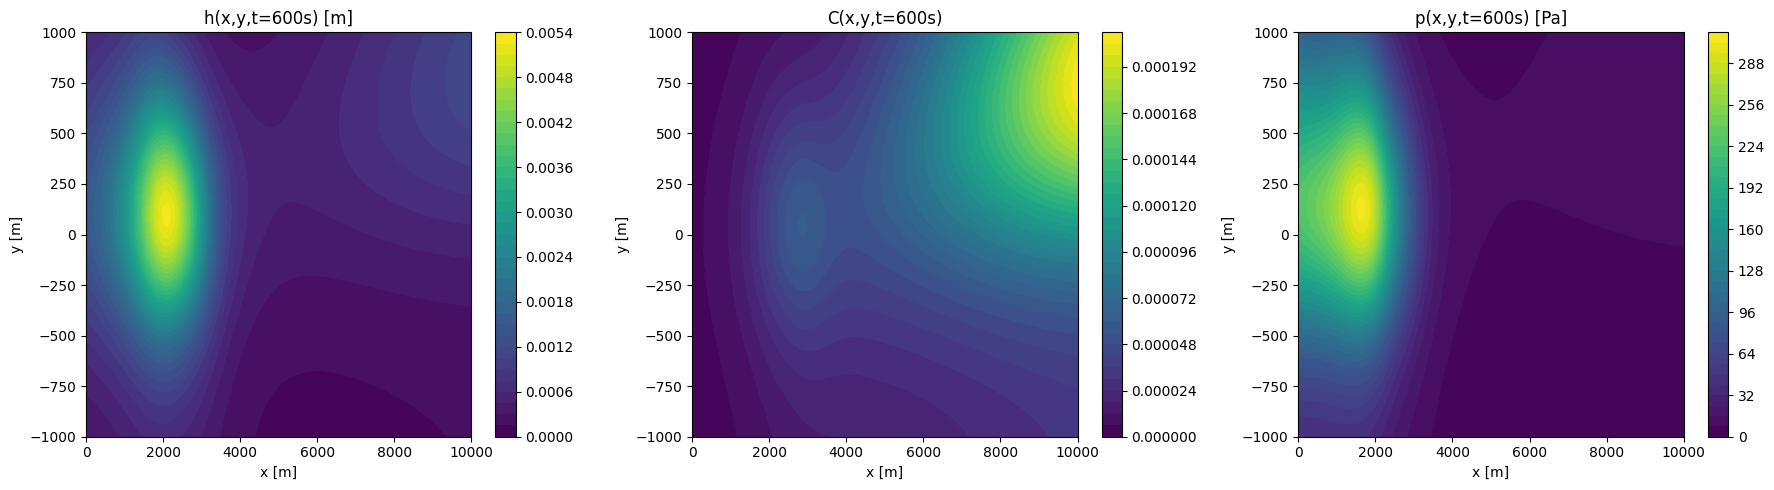

In [9]:
# ============================================================
# 12) PREDICCIÓN EN t*
# ============================================================
t_star = 600.0
Tf = np.full_like(Xf, t_star, dtype=np.float32)

h_pred, u_pred, v_pred, C_pred, p_pred = predict_fields(
    tf.convert_to_tensor(Xf),
    tf.convert_to_tensor(Yf),
    tf.convert_to_tensor(Tf)
)

h_map = h_pred.numpy().reshape(ny, nx)
C_map = C_pred.numpy().reshape(ny, nx)
p_map = p_pred.numpy().reshape(ny, nx)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.contourf(X, Y, h_map, levels=40)
plt.title(f"h(x,y,t={t_star:.0f}s) [m]")
plt.xlabel("x [m]"); plt.ylabel("y [m]")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.contourf(X, Y, C_map, levels=40)
plt.title(f"C(x,y,t={t_star:.0f}s)")
plt.xlabel("x [m]"); plt.ylabel("y [m]")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.contourf(X, Y, p_map, levels=40)
plt.title(f"p(x,y,t={t_star:.0f}s) [Pa]")
plt.xlabel("x [m]"); plt.ylabel("y [m]")
plt.colorbar()

plt.tight_layout()
plt.show()
